<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main (1).zip


In [22]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/project_data')

print("Main ZIP extracted successfully!")

Main ZIP extracted successfully!


In [23]:
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

print("Total .7z files found:", len(seven_zip_files))

for file in seven_zip_files:
    print(file)

Total .7z files found: 8
/content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0120.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0096.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0110.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0135.7z


In [24]:
!apt-get install p7zip-full -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [25]:
import os
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

for file in seven_zip_files:
    output_folder = file.replace('.7z', '')
    os.makedirs(output_folder, exist_ok=True)

    print("Extracting:", file)
    !7z x "{file}" -o"{output_folder}" -y

print("All .7z files extracted!")

Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/project_data/Underwater-Image-Data-set-main/                                                               1 file, 23128645 bytes (23 MiB)

Extracting archive: /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
--
Path = /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
Type = 7z
Physical Size = 23128645
Headers Size = 4780
Method = LZMA:23
Solid = +
Blocks = 1

  0%      6% - epoch_0115/img 100_gen.png                                 

In [26]:
image_files = []

for root, dirs, files in os.walk('/content/project_data'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            image_files.append(os.path.join(root, file))

print("Total images found:", len(image_files))

print("\nFirst 10 images:")
for img in image_files[:10]:
    print(img)

Total images found: 3694

First 10 images:
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 33_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 37_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 27_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 37_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 125_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 96_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 24_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 70_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 110_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 35_gen.png


In [27]:
from PIL import Image
import pandas as pd

image_info = []

for path in image_files:
    try:
        img = Image.open(path)

        image_info.append({
            'filename': os.path.basename(path),
            'path': path,
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'format': img.format
        })

    except Exception as e:
        print("Could not read:", path)

image_df = pd.DataFrame(image_info)

print("Total valid images:", len(image_df))
display(image_df.head())

Total valid images: 3694


,filename,path,width,height,mode,format
0,img 33_gen.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
1,img 37_input.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
2,img 27_target.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
3,img 37_target.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
4,img 125_gen.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG


In [28]:
print("Image Dimension Distribution:")

dimension_counts = (
    image_df.groupby(['width', 'height'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

display(dimension_counts.head(10))

Image Dimension Distribution:


,width,height,count
0,256,256,3694


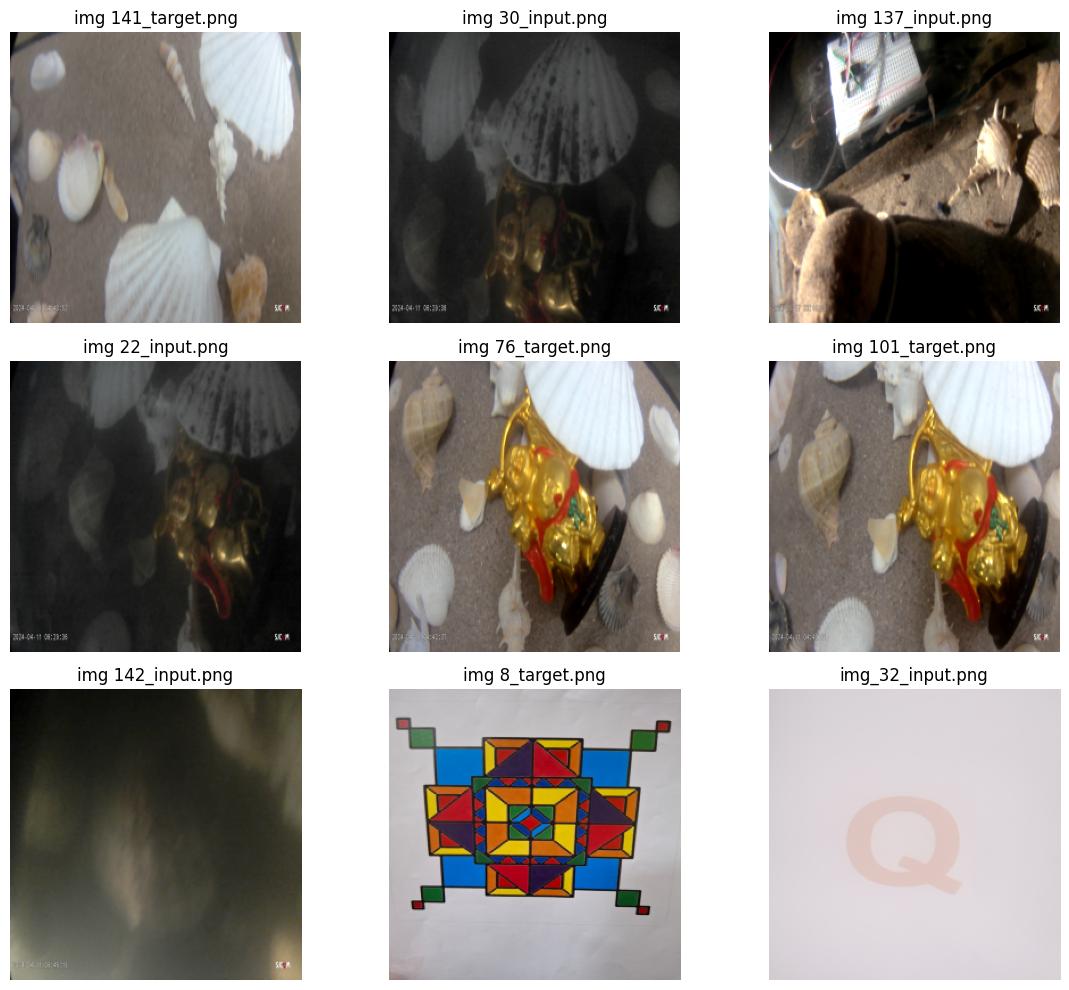

In [29]:
import random
import matplotlib.pyplot as plt

sample_count = min(9, len(image_files))
samples = random.sample(image_files, sample_count)

plt.figure(figsize=(12, 10))

for i, path in enumerate(samples):
    img = Image.open(path).convert('RGB')

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

def get_brightness(path):
    img = Image.open(path).convert('RGB')
    arr = np.array(img)
    return arr.mean()

brightness_data = []

for path in image_files:
    try:
        brightness_data.append({
            'path': path,
            'brightness': get_brightness(path)
        })
    except:
        pass

brightness_df = pd.DataFrame(brightness_data)

dark_samples = brightness_df.nsmallest(
    min(6, len(brightness_df)),
    'brightness'
)

display(dark_samples)

,path,brightness
3580,/content/project_data/Underwater-Image-Data-se...,0.974294
3685,/content/project_data/Underwater-Image-Data-se...,2.615275
3421,/content/project_data/Underwater-Image-Data-se...,3.498886
3415,/content/project_data/Underwater-Image-Data-se...,3.962728
3244,/content/project_data/Underwater-Image-Data-se...,3.980647
381,/content/project_data/Underwater-Image-Data-se...,6.449514


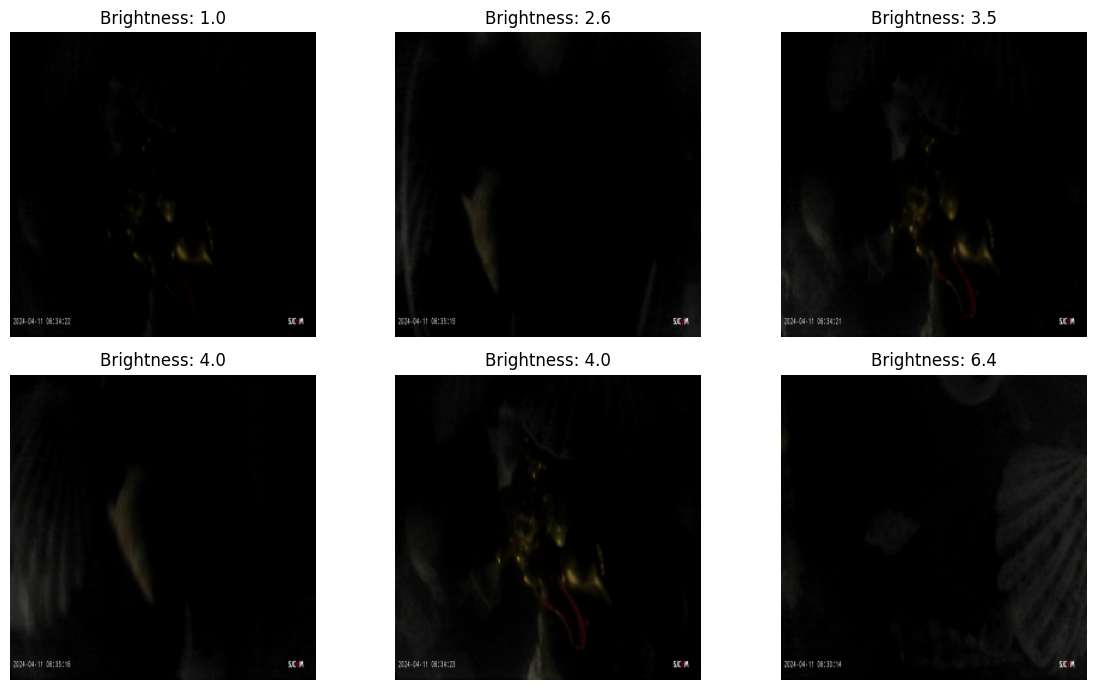

In [31]:
plt.figure(figsize=(12, 7))

for i, (_, row) in enumerate(dark_samples.iterrows()):
    img = Image.open(row['path']).convert('RGB')

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Brightness: {row['brightness']:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
corrupted_images = []

for path in image_files:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted_images.append(path)

print("Total corrupted images:", len(corrupted_images))

Total corrupted images: 0


In [33]:
print("Image Formats:")
print(image_df['format'].value_counts())

print("\nImage Color Modes:")
print(image_df['mode'].value_counts())

Image Formats:
format
PNG    3694
Name: count, dtype: int64

Image Color Modes:
mode
RGB    3694
Name: count, dtype: int64


In [34]:
#day 2 task

In [35]:
def calculate_image_stats(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)

    # Brightness
    brightness = np.mean(arr)

    # Contrast
    contrast = np.std(arr)

    # Average RGB values
    red_mean = np.mean(arr[:, :, 0])
    green_mean = np.mean(arr[:, :, 1])
    blue_mean = np.mean(arr[:, :, 2])

    return {
        "path": path,
        "filename": os.path.basename(path),
        "width": img.width,
        "height": img.height,
        "brightness": brightness,
        "contrast": contrast,
        "red_mean": red_mean,
        "green_mean": green_mean,
        "blue_mean": blue_mean
    }

In [36]:
stats = []

for path in image_files:
    try:
        stats.append(calculate_image_stats(path))
    except Exception as e:
        print("Error:", path)

stats_df = pd.DataFrame(stats)

print("Total images analyzed:", len(stats_df))
display(stats_df.head())

Total images analyzed: 3694


,path,filename,width,height,brightness,contrast,red_mean,green_mean,blue_mean
0,/content/project_data/Underwater-Image-Data-se...,img 33_gen.png,256,256,120.701436,58.233252,136.149918,121.726318,104.228073
1,/content/project_data/Underwater-Image-Data-se...,img 37_input.png,256,256,22.498718,18.330547,23.628784,22.743576,21.123795
2,/content/project_data/Underwater-Image-Data-se...,img 27_target.png,256,256,116.016424,58.111719,130.777023,117.965515,99.306732
3,/content/project_data/Underwater-Image-Data-se...,img 37_target.png,256,256,125.060872,61.716718,140.530487,126.746613,107.905518
4,/content/project_data/Underwater-Image-Data-se...,img 125_gen.png,256,256,132.109858,44.262166,138.669846,131.856216,125.803513


In [37]:
print("IMAGE QUALITY STATISTICS")

display(
    stats_df[
        ["brightness", "contrast", "red_mean", "green_mean", "blue_mean"]
    ].describe()
)

IMAGE QUALITY STATISTICS


,brightness,contrast,red_mean,green_mean,blue_mean
count,3694.000000,3694.000000,3694.000000,3694.000000,3694.000000
mean,111.428261,46.483096,117.727903,110.826504,105.730377
std,45.781968,18.448640,46.999327,44.721725,47.299455
min,0.974294,3.232109,1.106674,1.030060,0.786148
25%,102.228628,31.265691,106.663273,101.754501,93.275620
50%,123.136012,50.493920,131.624664,122.522209,111.292114
75%,133.608246,61.716718,140.487793,133.502029,129.349045
max,252.119314,91.467688,253.789703,252.064850,252.875595


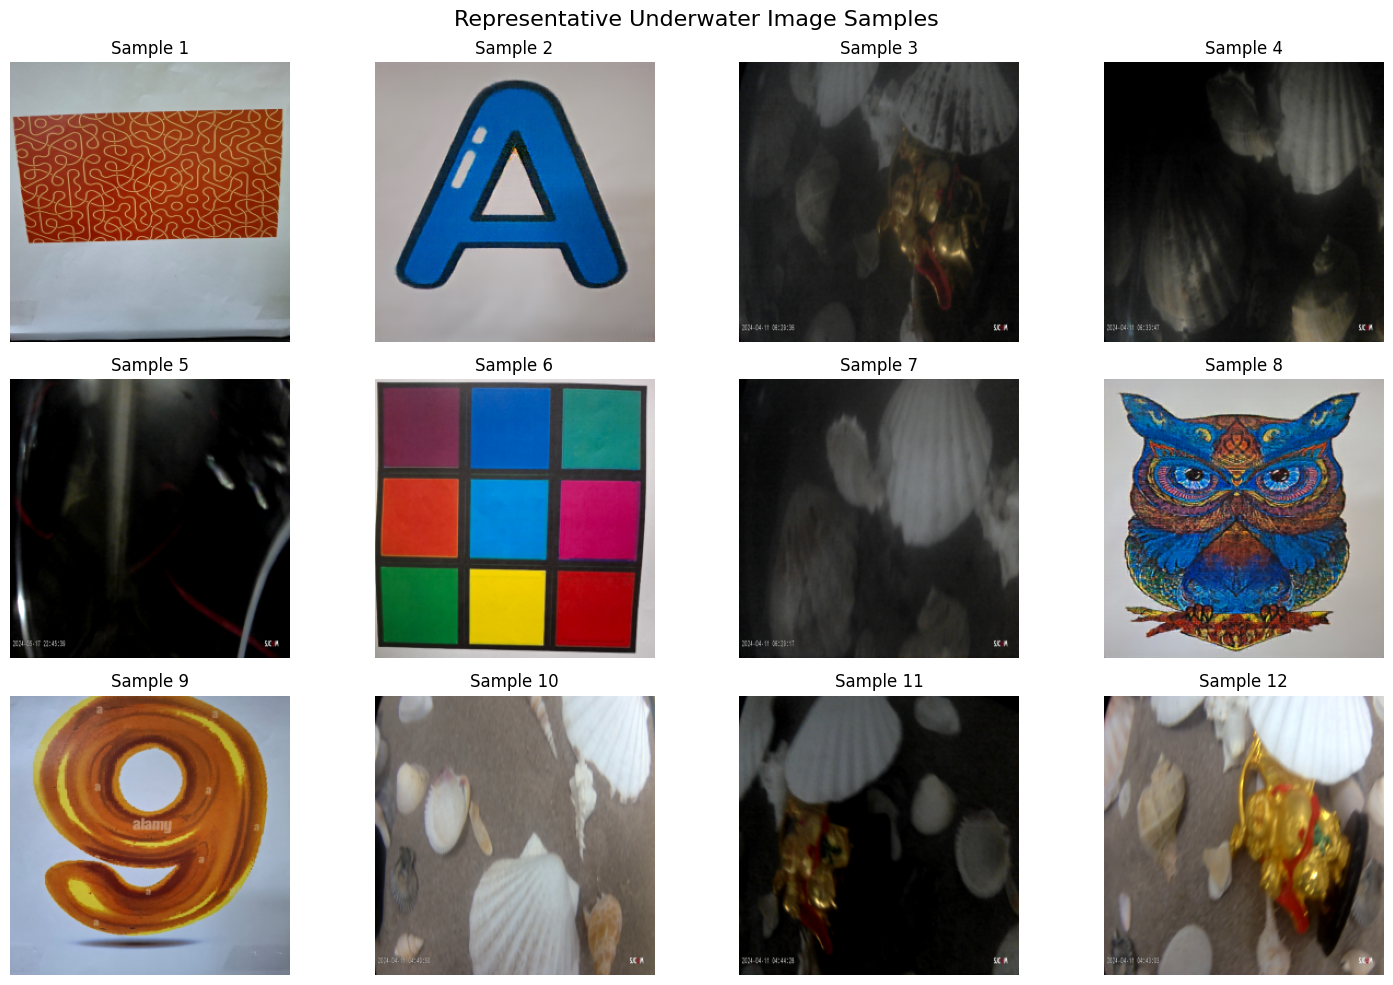

In [38]:
samples = random.sample(image_files, min(12, len(image_files)))

plt.figure(figsize=(15, 10))

for i, path in enumerate(samples):
    img = Image.open(path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Sample {i+1}")
    plt.axis("off")

plt.suptitle("Representative Underwater Image Samples", fontsize=16)
plt.tight_layout()
plt.show()

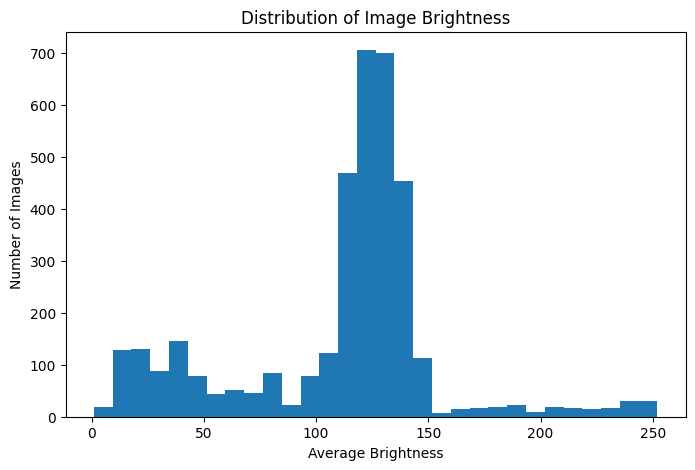

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(stats_df["brightness"], bins=30)

plt.xlabel("Average Brightness")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Brightness")

plt.show()

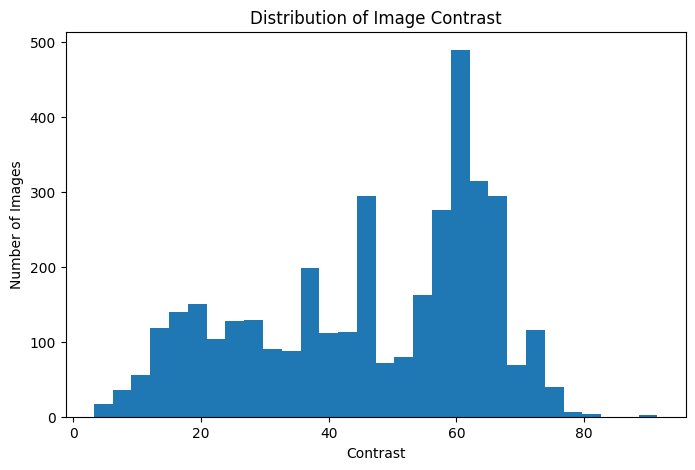

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(stats_df["contrast"], bins=30)

plt.xlabel("Contrast")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Contrast")

plt.show()

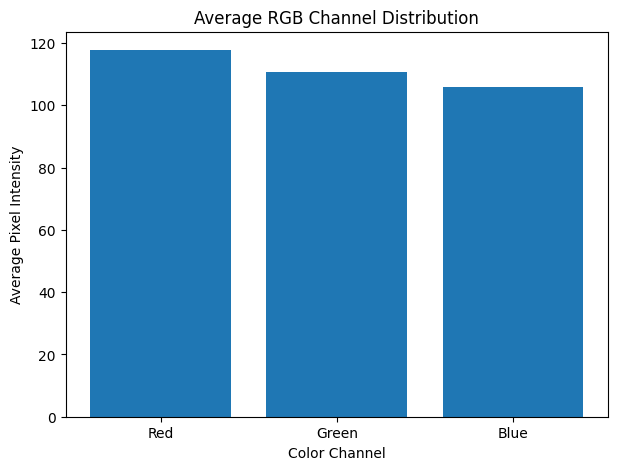

In [41]:
rgb_means = [
    stats_df["red_mean"].mean(),
    stats_df["green_mean"].mean(),
    stats_df["blue_mean"].mean()
]

channels = ["Red", "Green", "Blue"]

plt.figure(figsize=(7, 5))
plt.bar(channels, rgb_means)

plt.xlabel("Color Channel")
plt.ylabel("Average Pixel Intensity")
plt.title("Average RGB Channel Distribution")

plt.show()

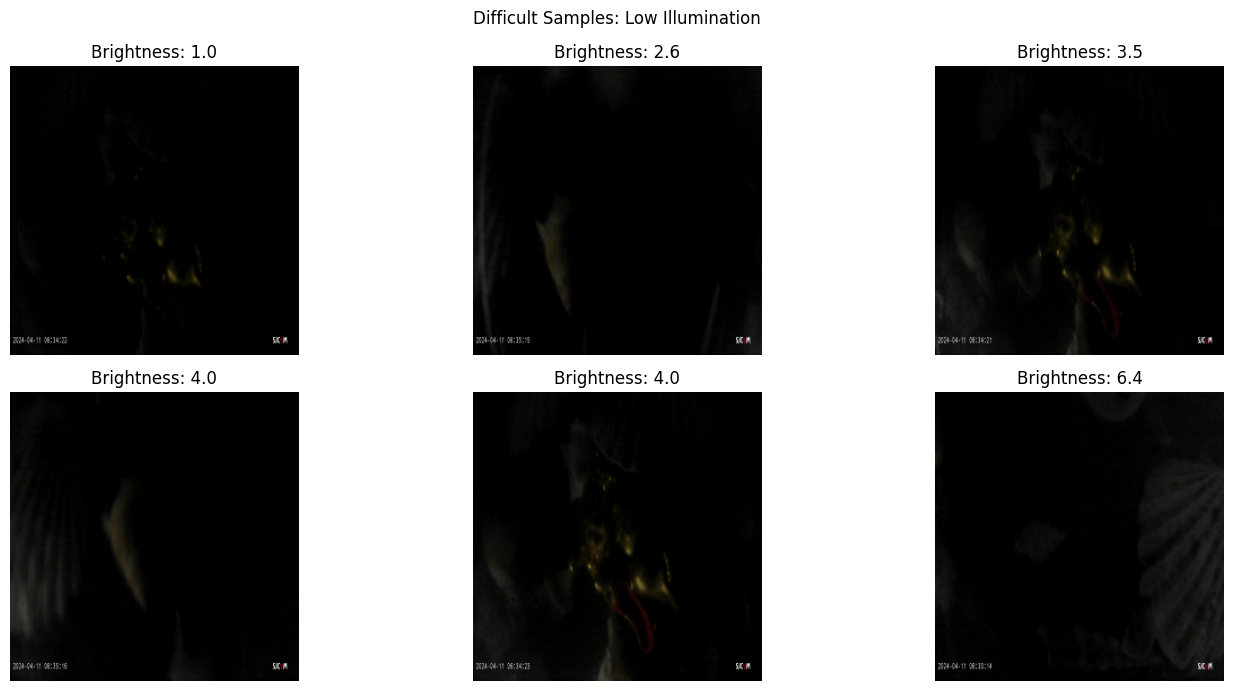

In [42]:
dark_samples = stats_df.nsmallest(6, "brightness")

plt.figure(figsize=(15, 7))

for i, (_, row) in enumerate(dark_samples.iterrows()):
    img = Image.open(row["path"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Brightness: {row['brightness']:.1f}")
    plt.axis("off")

plt.suptitle("Difficult Samples: Low Illumination")
plt.tight_layout()
plt.show()

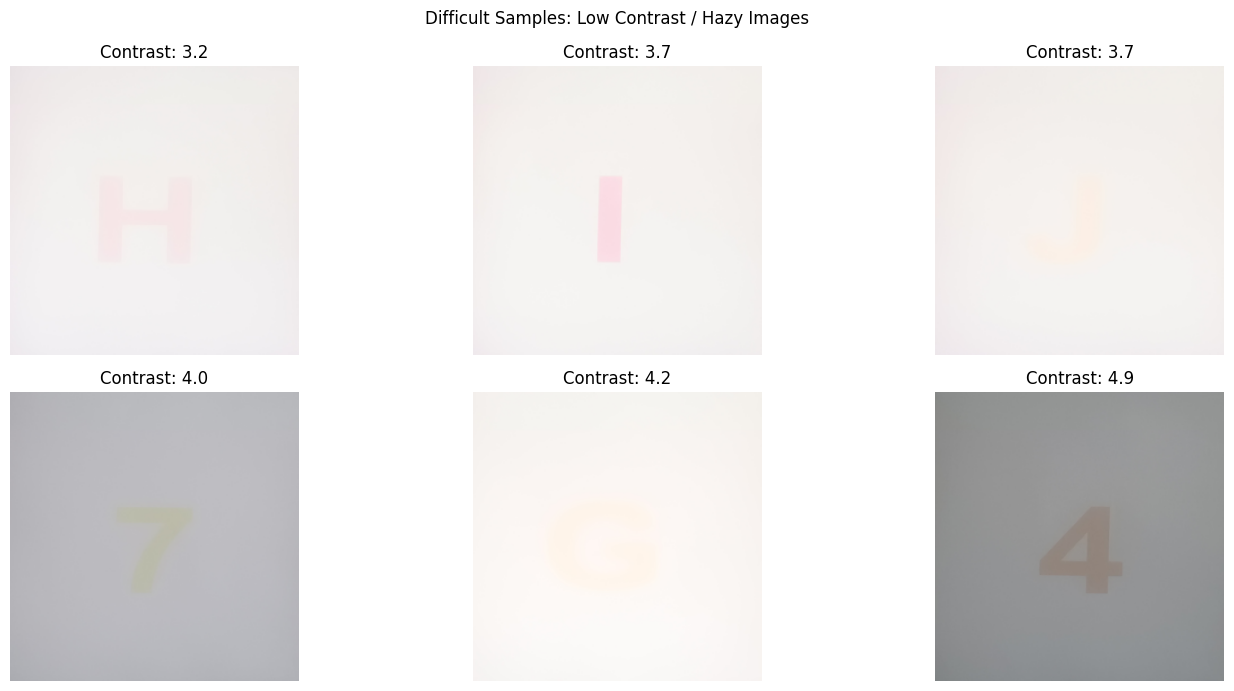

In [43]:
low_contrast = stats_df.nsmallest(6, "contrast")

plt.figure(figsize=(15, 7))

for i, (_, row) in enumerate(low_contrast.iterrows()):
    img = Image.open(row["path"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Contrast: {row['contrast']:.1f}")
    plt.axis("off")

plt.suptitle("Difficult Samples: Low Contrast / Hazy Images")
plt.tight_layout()
plt.show()

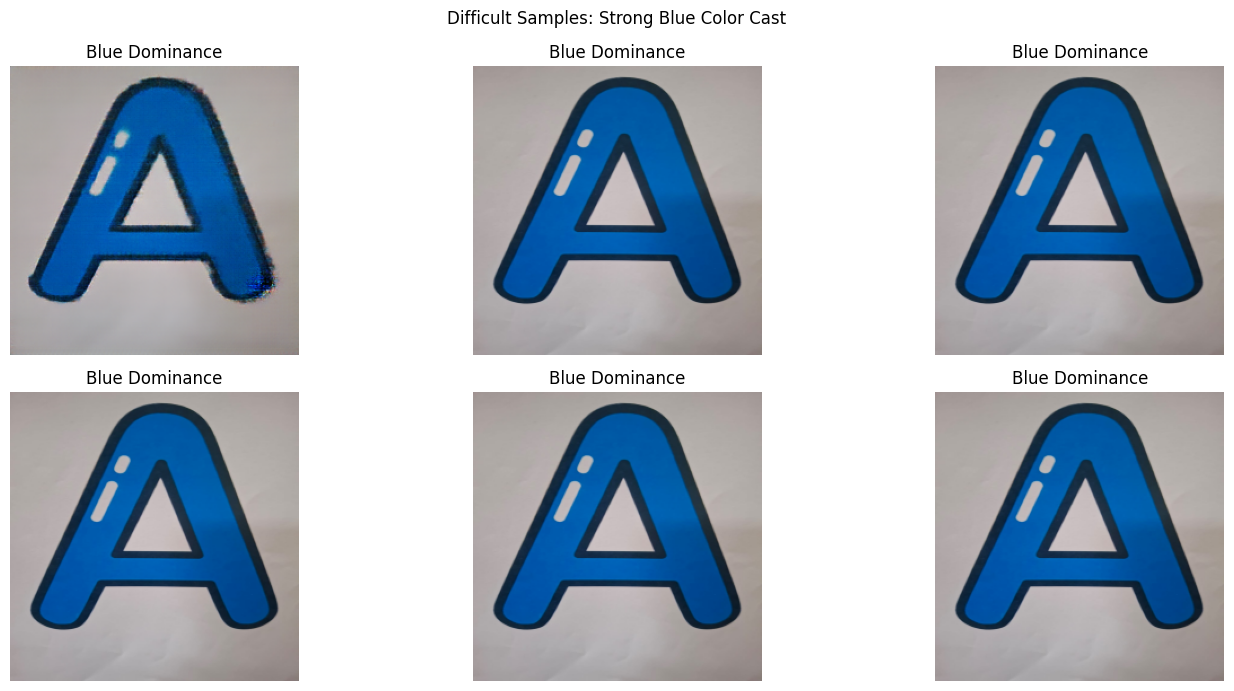

In [44]:
stats_df["blue_dominance"] = (
    stats_df["blue_mean"] -
    (stats_df["red_mean"] + stats_df["green_mean"]) / 2
)

blue_samples = stats_df.nlargest(6, "blue_dominance")

plt.figure(figsize=(15, 7))

for i, (_, row) in enumerate(blue_samples.iterrows()):
    img = Image.open(row["path"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Blue Dominance")
    plt.axis("off")

plt.suptitle("Difficult Samples: Strong Blue Color Cast")
plt.tight_layout()
plt.show()

In [45]:
summary = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Average Brightness",
        "Average Contrast",
        "Average Red",
        "Average Green",
        "Average Blue"
    ],
    "Value": [
        len(stats_df),
        stats_df["brightness"].mean(),
        stats_df["contrast"].mean(),
        stats_df["red_mean"].mean(),
        stats_df["green_mean"].mean(),
        stats_df["blue_mean"].mean()
    ]
})

display(summary)

,Metric,Value
0,Total Images,3694.000000
1,Average Brightness,111.428261
2,Average Contrast,46.483096
3,Average Red,117.727903
4,Average Green,110.826504
5,Average Blue,105.730377


In [46]:
def brightness_category(value):
    if value < 70:
        return "Dark"
    elif value < 140:
        return "Medium"
    else:
        return "Bright"

stats_df["brightness_category"] = stats_df["brightness"].apply(
    brightness_category
)

print(stats_df["brightness_category"].value_counts())

brightness_category
Medium    2446
Dark       718
Bright     530
Name: count, dtype: int64


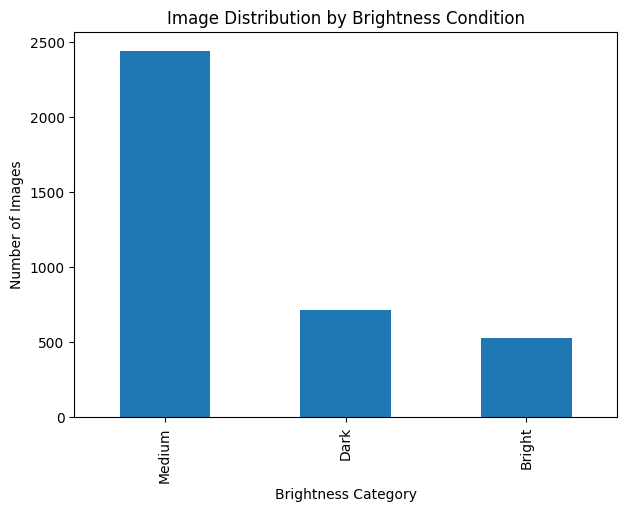

In [47]:
stats_df["brightness_category"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Brightness Category")
plt.ylabel("Number of Images")
plt.title("Image Distribution by Brightness Condition")

plt.show()